#Modelo Predictivo de Visibilidad y Seguridad Vial en la RN3


##Introducción
La Ruta Nacional N.º 3 es la principal conexión terrestre dentro de la Isla Grande de Tierra del Fuego y resulta fundamental para unir ciudades, transportar mercadería y permitir el traslado diario de muchas personas. Sin embargo, quienes transitamos habitualmente esta ruta sabemos que las condiciones climáticas representan un problema constante, especialmente en sectores como el Paso Garibaldi, donde el relieve montañoso y el clima fueguino generan situaciones muy peligrosas para conducir.
En muchas ocasiones, al trasladarme dentro de la isla, pude observar cómo la niebla densa, la niebla de hielo y el viento blanco reducen la visibilidad de forma repentina, convirtiendo la conducción en una situación de alto riesgo. En cuestión de minutos, la ruta puede quedar cubierta por una especie de “pared” de niebla o nieve en suspensión que dificulta la orientación de los conductores y aumenta considerablemente las probabilidades de accidentes. Esta problemática se vio reflejada en los últimos años con numerosos despistes y situaciones de emergencia en distintos sectores de la Ruta Nacional N.º 3, involucrando vehículos particulares, camiones y transportes de pasajeros afectados por las condiciones climáticas adversas.
A partir de esta problemática surge la importancia de este proyecto, que busca utilizar datos meteorológicos históricos para desarrollar una herramienta predictiva capaz de anticipar escenarios de baja visibilidad. Contar con un modelo de este tipo permitiría mejorar la toma de decisiones sobre la transitabilidad de la ruta, emitir alertas tempranas y contribuir a una mayor seguridad para todas las personas que circulan por este corredor tan importante de la provincia.


##Objetivo General
Desarrollar un modelo de Aprendizaje Automático supervisado, utilizando la librería scikit-learn, que permita clasificar de manera temprana condiciones de riesgo vial por pérdida crítica de visibilidad en la Ruta Nacional N.º 3 a partir de variables meteorológicas locales, con el objetivo de emitir alertas tempranas sobre posibles escenarios de baja visibilidad y peligro para la circulación.


#Origen del dataset
Los datos meteorológicos utilizados en este proyecto fueron obtenidos de
Meteostat, una plataforma de acceso abierto que brinda información climática
histórica de distintas partes del mundo. Para el análisis se seleccionaron las
estaciones meteorológicas oficiales de las dos principales ciudades de la
provincia de Tierra del Fuego: Ushuaia (representativa de la zona sur y
cordillerana) y Río Grande (representativa de la zona norte y esteparia).
Durante la recopilación de los datos surgió una dificultad importante. Al
descargar grandes períodos de tiempo de manera automática, algunas variables
relevantes no se incluían correctamente, especialmente la columna coco (Código
de Condición Climática), que resulta fundamental para el entrenamiento
supervisado de los modelos utilizados en este trabajo.
Para solucionar este problema, se optó por realizar las descargas en períodos
más pequeños, organizados de forma semanal para cada ciudad. De esta
manera se logró obtener la información completa y garantizar la presencia de
todas las variables necesarias. El período analizado abarca desde enero de 2023
hasta abril de 2026.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Carga de data set

In [12]:
dataset = pd.read_excel('dataset Rio Grande- Ushuaia.xlsx')

In [13]:
dataset.head()

,ciudad,time,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
0,Ushuaia,2023-01-01 00:00:00,11.5,3.5,58.0,0.0,NaN,320.0,14.8,NaN,977.3,NaN,4.0
1,Rio Grande,2023-01-01 00:00:00,9.0,4.0,71.0,0.0,NaN,290.0,38.9,NaN,982.0,NaN,3.0
2,Ushuaia,2023-01-01 01:00:00,8.2,5.7,84.0,0.0,NaN,230.0,57.6,NaN,978.2,NaN,7.0
3,Rio Grande,2023-01-01 01:00:00,7.6,4.9,83.0,0.0,NaN,290.0,55.4,NaN,982.6,NaN,3.0
4,Ushuaia,2023-01-01 02:00:00,7.9,3.9,76.0,0.0,NaN,230.0,46.4,NaN,979.3,NaN,7.0


### Buscar registros duplicados según fecha y ciudad

In [14]:
duplicados = dataset[dataset.duplicated(
    subset=['time', 'ciudad'],
    keep=False
)]

print(duplicados.sort_values(['time', 'ciudad']))

        ciudad time  temp  dwpt  rhum  prcp  snow   wdir  wspd  wpgt    pres  \
58200  Ushuaia  NaT   7.0   1.1  66.0   0.0   NaN  110.0   4.0   NaN  1002.0   
58201  Ushuaia  NaT   6.0   2.1  76.0   0.0   NaN  360.0   4.0   NaN  1001.0   
58202  Ushuaia  NaT   6.0   2.1  76.0   0.0   NaN  360.0  11.0   NaN  1001.0   
58203  Ushuaia  NaT   7.0   2.1  71.0   0.0   NaN   50.0   9.0   NaN  1001.0   
58204  Ushuaia  NaT   7.0   3.1  76.0   0.0   NaN   50.0   9.0   NaN   999.0   
...        ...  ...   ...   ...   ...   ...   ...    ...   ...   ...     ...   
58363  Ushuaia  NaT  13.0   4.9  58.0   0.0   NaN  240.0  24.0   NaN  1003.0   
58364  Ushuaia  NaT  12.0   4.9  62.0   0.0   NaN  230.0  26.0  24.0  1003.0   
58365  Ushuaia  NaT  12.0   4.9  62.0   0.0   NaN  230.0  26.0   NaN  1002.0   
58366  Ushuaia  NaT  11.0   5.1  67.0   0.0   NaN  230.0  17.0   NaN  1002.0   
58367  Ushuaia  NaT  11.0   5.1  67.0   0.0   NaN  228.0   1.0   NaN  1002.0   

       tsun  coco  
58200   NaN   3.0  

### Variables meteorológicas a utilizar

In [ ]:
variables = [
    'temp', 'dwpt', 'rhum', 'prcp', 'snow',
    'wdir', 'wspd', 'wpgt', 'pres', 'tsun', 'coco'
]

### Reestructurar el dataset para tener una fila por fecha y columnas separadas para cada ciudad

In [15]:
df_modelo = pd.pivot_table(
    dataset,
    index='time',
    columns='ciudad',
    values=variables,
    aggfunc='mean'
)



### Unificar nombres de columnas

In [ ]:
df_modelo.columns = [
    f'{var}_{ciudad}'
    for var, ciudad in df_modelo.columns
]

### Convertir el índice temporal nuevamente en columna

In [ ]:
df_modelo = df_modelo.reset_index()

### Contar duplicados restantes

In [16]:
print(
    dataset.duplicated(
        subset=['time', 'ciudad']
    ).sum()
)

167


### Obtener nuevamente los registros duplicados.

In [17]:
duplicados = dataset[dataset.duplicated(
    subset=['time','ciudad'],
    keep=False
)]

print(duplicados[['time','ciudad']].sort_values(['time','ciudad']))

      time   ciudad
58200  NaT  Ushuaia
58201  NaT  Ushuaia
58202  NaT  Ushuaia
58203  NaT  Ushuaia
58204  NaT  Ushuaia
...    ...      ...
58363  NaT  Ushuaia
58364  NaT  Ushuaia
58365  NaT  Ushuaia
58366  NaT  Ushuaia
58367  NaT  Ushuaia

[168 rows x 2 columns]


### Mostrar cantidad de filas y columnas del conjunto de duplicados.

In [18]:
print(duplicados.shape)

(168, 13)


** ANÁLISIS DE FECHAS FALTANTES**

### Contar registros con fecha faltante

In [19]:
print(dataset['time'].isna().sum())

168


### Verificar nuevamente la cantidad de duplicados.

In [20]:
print(
    dataset.duplicated(
        subset=['time','ciudad']
    ).sum()
)

167


### Extraer las filas que tienen fecha faltante.

In [21]:
filas_sin_fecha = dataset[dataset['time'].isna()]
print(filas_sin_fecha.head())

        ciudad time  temp  dwpt  rhum  prcp  snow   wdir  wspd  wpgt    pres  \
58200  Ushuaia  NaT   7.0   1.1  66.0   0.0   NaN  110.0   4.0   NaN  1002.0   
58201  Ushuaia  NaT   6.0   2.1  76.0   0.0   NaN  360.0   4.0   NaN  1001.0   
58202  Ushuaia  NaT   6.0   2.1  76.0   0.0   NaN  360.0  11.0   NaN  1001.0   
58203  Ushuaia  NaT   7.0   2.1  71.0   0.0   NaN   50.0   9.0   NaN  1001.0   
58204  Ushuaia  NaT   7.0   3.1  76.0   0.0   NaN   50.0   9.0   NaN   999.0   

       tsun  coco  
58200   NaN   3.0  
58201   NaN   2.0  
58202   NaN   2.0  
58203   NaN   3.0  
58204   NaN   3.0  


#### Analizar a qué ciudad pertenecen los registros sin información temporal.

In [22]:
print(dataset[dataset['time'].isna()]['ciudad'].value_counts())

ciudad
Ushuaia    168
Name: count, dtype: int64


### Mostrar las primeras 20 filas con fecha faltante.

In [23]:
dataset[dataset['time'].isna()].head(20)

,ciudad,time,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
58200,Ushuaia,NaT,7.0,1.1,66.0,0.0,NaN,110.0,4.0,NaN,1002.0,NaN,3.0
58201,Ushuaia,NaT,6.0,2.1,76.0,0.0,NaN,360.0,4.0,NaN,1001.0,NaN,2.0
58202,Ushuaia,NaT,6.0,2.1,76.0,0.0,NaN,360.0,11.0,NaN,1001.0,NaN,2.0
58203,Ushuaia,NaT,7.0,2.1,71.0,0.0,NaN,50.0,9.0,NaN,1001.0,NaN,3.0
58204,Ushuaia,NaT,7.0,3.1,76.0,0.0,NaN,50.0,9.0,NaN,999.0,NaN,3.0
58205,Ushuaia,NaT,5.0,2.0,81.0,0.0,NaN,21.0,2.0,NaN,999.0,NaN,3.0
58206,Ushuaia,NaT,6.0,3.0,81.0,0.0,NaN,240.0,11.0,NaN,998.0,NaN,3.0
58207,Ushuaia,NaT,8.0,2.0,66.0,0.0,NaN,310.0,9.0,NaN,998.0,NaN,3.0
58208,Ushuaia,NaT,9.0,2.1,62.0,0.0,NaN,20.0,17.0,NaN,998.0,NaN,3.0
58209,Ushuaia,NaT,11.0,3.1,58.0,0.0,NaN,184.0,9.0,NaN,997.0,NaN,3.0


# Limpieza del dataset


### Eliminar registros que no poseen fecha

In [24]:
dataset = dataset.dropna(subset=['time'])

### Confirmar que no quedan valores faltantes

In [25]:
print(dataset['time'].isna().sum())

0


# Generacion del dataset finañ

In [26]:
variables = [
    'temp','dwpt','rhum','prcp','snow',
    'wdir','wspd','wpgt','pres','tsun','coco'
]

df_modelo = pd.pivot_table(
    dataset,
    index='time',
    columns='ciudad',
    values=variables
)

df_modelo.columns = [
    f'{var}_{ciudad}'
    for var, ciudad in df_modelo.columns
]

df_modelo = df_modelo.reset_index()

print(df_modelo.shape)
df_modelo.head()

(29184, 27)


,time,coco_Rio Grande,coco_Ushuaia,coco_ciudad,dwpt_Rio Grande,dwpt_Ushuaia,dwpt_ciudad,prcp_Rio Grande,prcp_Ushuaia,prcp_ciudad,...,temp_Ushuaia,temp_ciudad,wdir_Rio Grande,wdir_Ushuaia,wdir_ciudad,wpgt_Rio Grande,wpgt_Ushuaia,wspd_Rio Grande,wspd_Ushuaia,wspd_ciudad
0,2023-01-01 00:00:00,3.0,4.0,NaN,4.0,3.5,NaN,0.0,0.0,NaN,...,11.5,NaN,290.0,320.0,NaN,NaN,NaN,38.9,14.8,NaN
1,2023-01-01 01:00:00,3.0,7.0,NaN,4.9,5.7,NaN,0.0,0.0,NaN,...,8.2,NaN,290.0,230.0,NaN,NaN,NaN,55.4,57.6,NaN
2,2023-01-01 02:00:00,3.0,7.0,NaN,4.2,3.9,NaN,0.0,0.0,NaN,...,7.9,NaN,290.0,230.0,NaN,NaN,NaN,57.6,46.4,NaN
3,2023-01-01 03:00:00,3.0,7.0,NaN,2.4,2.9,NaN,0.0,0.0,NaN,...,8.0,NaN,270.0,230.0,NaN,NaN,NaN,44.6,55.4,NaN
4,2023-01-01 04:00:00,3.0,7.0,NaN,1.9,2.8,NaN,0.0,0.1,NaN,...,7.5,NaN,270.0,230.0,NaN,NaN,NaN,50.0,53.6,NaN


### Eliminar todas las columnas que terminen en '_ciudad'

In [27]:
columnas_a_borrar = [col for col in df_modelo.columns if col.endswith('_ciudad')]
df_modelo = df_modelo.drop(columns=columnas_a_borrar)
df_modelo.head()

,time,coco_Rio Grande,coco_Ushuaia,dwpt_Rio Grande,dwpt_Ushuaia,prcp_Rio Grande,prcp_Ushuaia,pres_Rio Grande,pres_Ushuaia,rhum_Rio Grande,rhum_Ushuaia,temp_Rio Grande,temp_Ushuaia,wdir_Rio Grande,wdir_Ushuaia,wpgt_Rio Grande,wpgt_Ushuaia,wspd_Rio Grande,wspd_Ushuaia
0,2023-01-01 00:00:00,3.0,4.0,4.0,3.5,0.0,0.0,982.0,977.3,71.0,58.0,9.0,11.5,290.0,320.0,NaN,NaN,38.9,14.8
1,2023-01-01 01:00:00,3.0,7.0,4.9,5.7,0.0,0.0,982.6,978.2,83.0,84.0,7.6,8.2,290.0,230.0,NaN,NaN,55.4,57.6
2,2023-01-01 02:00:00,3.0,7.0,4.2,3.9,0.0,0.0,983.5,979.3,81.0,76.0,7.2,7.9,290.0,230.0,NaN,NaN,57.6,46.4
3,2023-01-01 03:00:00,3.0,7.0,2.4,2.9,0.0,0.0,984.6,979.7,74.0,70.0,6.7,8.0,270.0,230.0,NaN,NaN,44.6,55.4
4,2023-01-01 04:00:00,3.0,7.0,1.9,2.8,0.0,0.1,985.2,980.4,70.0,72.0,7.0,7.5,270.0,230.0,NaN,NaN,50.0,53.6



### Estructura general del dataset pivoteado

In [42]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29184 entries, 0 to 29183
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   time             29184 non-null  datetime64[ns]
 1   coco_Rio Grande  28708 non-null  float64       
 2   coco_Ushuaia     29013 non-null  float64       
 3   dwpt_Rio Grande  29151 non-null  float64       
 4   dwpt_Ushuaia     29012 non-null  float64       
 5   prcp_Rio Grande  28708 non-null  float64       
 6   prcp_Ushuaia     28537 non-null  float64       
 7   pres_Rio Grande  29142 non-null  float64       
 8   pres_Ushuaia     29013 non-null  float64       
 9   rhum_Rio Grande  29151 non-null  float64       
 10  rhum_Ushuaia     29012 non-null  float64       
 11  temp_Rio Grande  29156 non-null  float64       
 12  temp_Ushuaia     29013 non-null  float64       
 13  wdir_Rio Grande  29154 non-null  float64       
 14  wdir_Ushuaia     29013 non-null  float


### Resumen estadístico de las variables principales de ambas ciudades

In [40]:
print(df_modelo[['temp_Rio Grande', 'temp_Ushuaia', 'rhum_Rio Grande', 'rhum_Ushuaia', 'prcp_Rio Grande', 'prcp_Ushuaia']].describe())

       temp_Rio Grande  temp_Ushuaia  rhum_Rio Grande  rhum_Ushuaia  \
count     29156.000000  29013.000000     29151.000000  29012.000000   
mean          6.198518      6.400510        74.310007     73.239005   
std           5.393077      4.221587        17.644447     13.597683   
min         -12.600000     -6.000000        20.000000     19.000000   
25%           2.200000      3.400000        62.000000     64.000000   
50%           6.000000      6.000000        78.000000     75.000000   
75%          10.000000      9.000000        88.000000     84.000000   
max          25.000000     25.000000       100.000000    100.000000   

       prcp_Rio Grande  prcp_Ushuaia  
count     28708.000000  28537.000000  
mean          0.054783      0.119179  
std           0.235702      0.320964  
min           0.000000      0.000000  
25%           0.000000      0.000000  
50%           0.000000      0.000000  
75%           0.000000      0.100000  
max           8.200000      7.500000  


# Graficos


### Distribución de Temperaturas (Ushuaia vs Río Grande)

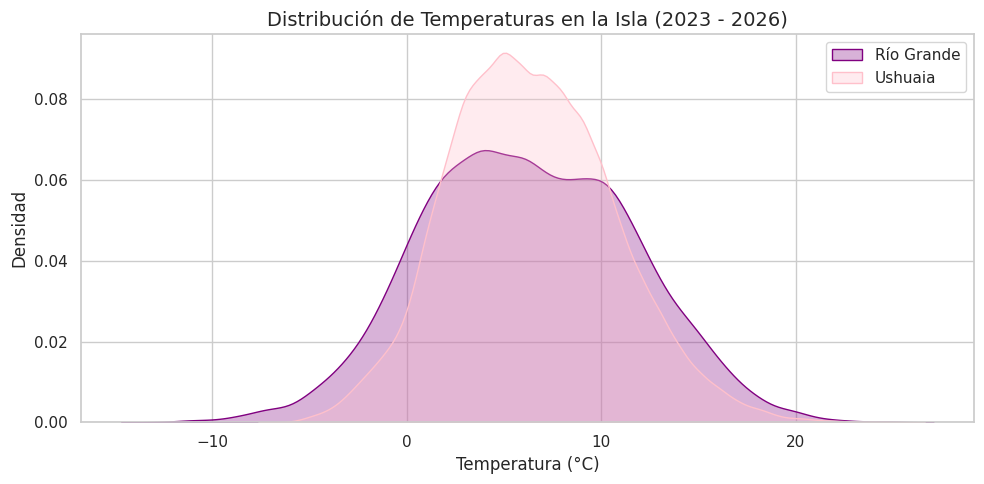

In [36]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df_modelo['temp_Rio Grande'], label='Río Grande', fill=True, color='purple', alpha=0.3)
sns.kdeplot(df_modelo['temp_Ushuaia'], label='Ushuaia', fill=True, color='pink', alpha=0.3)
plt.title('Distribución de Temperaturas en la Isla (2023 - 2026)', fontsize=14)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

###Relación de Humedad Relativa entre ambas ciudades (Scatter Plot)

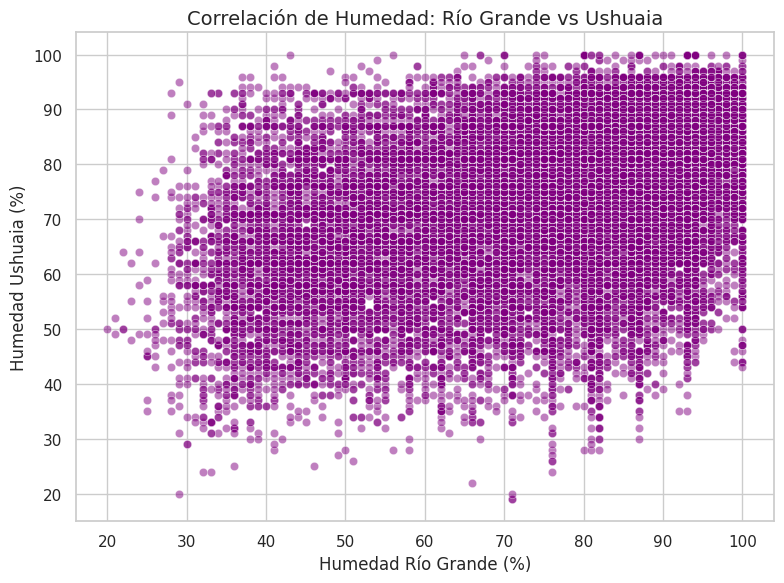

In [33]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_modelo, x='rhum_Rio Grande', y='rhum_Ushuaia', alpha=0.5, color='purple')
plt.title('Correlación de Humedad: Río Grande vs Ushuaia', fontsize=14)
plt.xlabel('Humedad Río Grande (%)')
plt.ylabel('Humedad Ushuaia (%)')
plt.tight_layout()
plt.show()

###Comportamiento de las Precipitaciones por ciudad

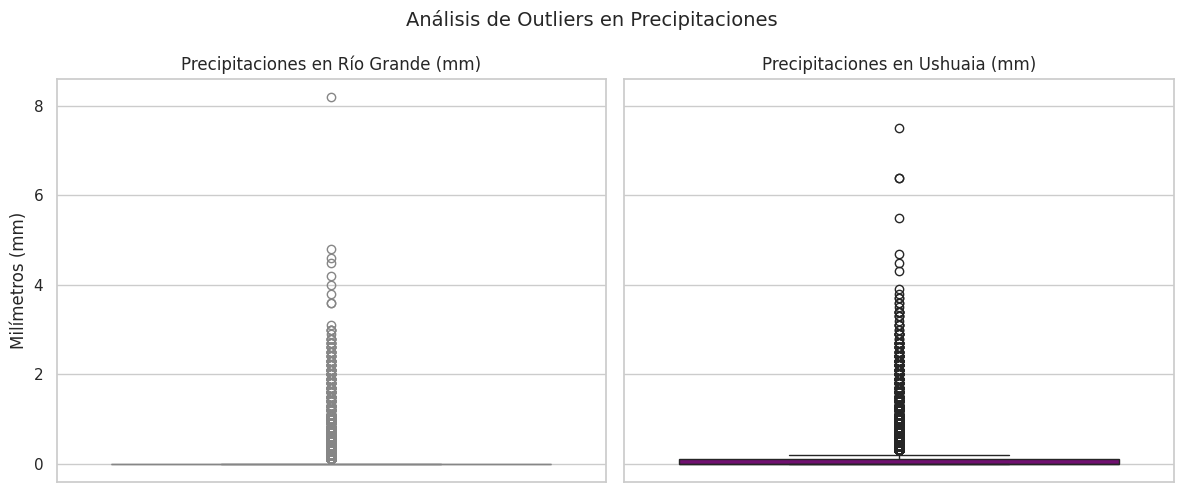

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.boxplot(data=df_modelo, y='prcp_Rio Grande', ax=axes[0], color='pink')
axes[0].set_title('Precipitaciones en Río Grande (mm)')
axes[0].set_ylabel('Milímetros (mm)')

sns.boxplot(data=df_modelo, y='prcp_Ushuaia', ax=axes[1], color='purple')
axes[1].set_title('Precipitaciones en Ushuaia (mm)')

plt.suptitle('Análisis de Outliers en Precipitaciones', fontsize=14)
plt.tight_layout()
plt.show()

# Descripción del dataset
El dataset final utilizado para el proyecto está compuesto por 29.184 registros y 19
variables. La información corresponde a observaciones meteorológicas de las
ciudades de Río Grande y Ushuaia, organizadas en función de una variable
temporal (time) almacenada en formato fecha y hora. Las restantes 18 variables
son de tipo numérico (float64) e incluyen mediciones relacionadas con
temperatura (temp), punto de rocío (dwpt), humedad relativa (rhum),
precipitaciones (prcp), presión atmosférica (pres), dirección del viento (wdir),
velocidad del viento (wspd), ráfagas máximas de viento (wpgt) y condición
meteorológica (coco) para ambas ciudades. El conjunto de datos presenta
algunos valores faltantes, principalmente en las variables de ráfagas máximas de
viento (wpgt_Rio Grande y wpgt_Ushuaia), mientras que el resto de las variables
cuenta con una cobertura superior al 97% de los registros. El tamaño total del
dataset en memoria es de aproximadamente 4,2 MB.
El análisis descriptivo de las principales variables meteorológicas muestra que
las temperaturas medias registradas fueron de 6,20 °C en Río Grande y 6,40 °C en
Ushuaia, con valores que oscilaron entre -12,6 °C y 25 °C en Río Grande, y entre -6
°C y 25 °C en Ushuaia. La humedad relativa presentó promedios elevados en
ambas ciudades, alcanzando 74,31 % en Río Grande y 73,24 % en Ushuaia, lo que
refleja las características climáticas predominantes de la región. Respecto a las
precipitaciones, se observó una media de 0,055 mm en Río Grande y 0,119 mm en
Ushuaia, aunque la mediana fue de 0 mm en ambos casos, indicando que la
mayoría de los registros no presentan precipitaciones y que los eventos de lluvia
se concentran en determinados períodos. Asimismo, las precipitaciones máximas
alcanzaron 8,2 mm en Río Grande y 7,5 mm en Ushuaia, evidenciando la
ocurrencia ocasional de eventos de mayor intensidad. En general, las
distribuciones muestran una importante variabilidad térmica y niveles de
humedad elevados, características propias del clima fueguino.
##Distribución de Temperaturas  (Ushuaia vs Río Grande)
El gráfico de densidad permite
observar las diferencias en el
comportamiento
de
las
temperaturas entre Río Grande y
Ushuaia. En Río Grande, la
distribución es más amplia, lo que
indica una mayor variación
térmica a lo largo del tiempo, registrándose tanto temperaturas muy bajas como
valores más elevados durante los meses cálidos. En cambio, Ushuaia presenta
una distribución más concentrada, con temperaturas que tienden a mantenerse
dentro de un rango más estable. Esto puede explicarse teniendo en cuenta la
influencia marítima del Canal Beagle, que contribuye a moderar las variaciones
extremas de temperatura.
Desde el punto de vista del modelo, estas diferencias resultan relevantes ya que
permiten identificar patrones climáticos distintos entre ambas ciudades. La
combinación de temperaturas registradas en cada localidad puede aportar
información útil para detectar la probabilidad de congelamiento diferencial en
los tramos intermedios de la calzada  

## Relación de Humedad Relativa entre ambas ciudades (Scatter Plot)
El gráfico de dispersión muestra
que la mayor parte de las
observaciones se concentra en
valores altos de humedad relativa
para ambas ciudades. Esto indica
que la humedad es una
característica frecuente en la
región. Sin embargo, también se
observan diferencias entre los
valores
registrados
en cada
localidad, lo que demuestra que las
condiciones
atmosféricas
no
siempre evolucionan de la misma
manera.
Para el modelo, esta situación es beneficiosa porque ambas variables aportan
información complementaria. Analizar simultáneamente la humedad de Río
Grande y Ushuaia puede ayudar a identificar distintos escenarios climáticos que
podrían afectar las condiciones de circulación en la Ruta Nacional Nº 3.
## Comportamiento de las Precipitaciones por ciudad
Los diagramas de caja muestran que la mayoría de los registros presentan
precipitaciones nulas o muy bajas, algo esperable considerando que gran parte
de los días no se registran eventos significativos de lluvia o nieve. No obstante,
también aparecen valores extremos que representan episodios de
precipitaciones más intensas.
Estos valores no fueron considerados errores ni eliminados durante el proceso
de limpieza, ya que corresponden a fenómenos meteorológicos reales. Además,
resultan especialmente importantes para el proyecto porque pueden estar
asociados a situaciones de mayor riesgo para la circulación vehicular. Los
modelos seleccionados, como Árboles de Decisión y Random Forest, pueden trabajar adecuadamente con este tipo de valores extremos y utilizarlos para
mejorar la identificación de escenarios críticos.